In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [119]:
df = pd.read_csv('credit_risk_dataset.csv')

In [120]:
df.head(5)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


checking for duplicates and dropping if any 

In [121]:
df.duplicated().sum()

np.int64(165)

In [122]:
df.drop_duplicates(inplace= True)

In [123]:
df.info()

<class 'pandas.DataFrame'>
Index: 32416 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32416 non-null  int64  
 1   person_income               32416 non-null  int64  
 2   person_home_ownership       32416 non-null  str    
 3   person_emp_length           31529 non-null  float64
 4   loan_intent                 32416 non-null  str    
 5   loan_grade                  32416 non-null  str    
 6   loan_amnt                   32416 non-null  int64  
 7   loan_int_rate               29321 non-null  float64
 8   loan_status                 32416 non-null  int64  
 9   loan_percent_income         32416 non-null  float64
 10  cb_person_default_on_file   32416 non-null  str    
 11  cb_person_cred_hist_length  32416 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.2 MB


<Axes: xlabel='person_emp_length', ylabel='Count'>

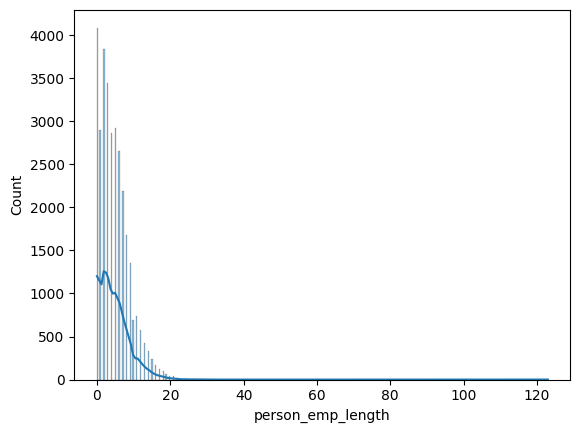

In [124]:
sns.histplot(df['person_emp_length'], kde=True)

In [125]:
df[df['person_emp_length']>20]['person_emp_length'].value_counts()

person_emp_length
21.0     38
22.0     19
24.0     10
23.0     10
25.0      8
26.0      6
27.0      5
31.0      4
28.0      3
123.0     2
30.0      2
41.0      1
34.0      1
29.0      1
38.0      1
Name: count, dtype: int64

there are two values of 123 which is a outliner since other values are less than 40 it is highly weighted so removing the two columns

In [126]:
df = df[df['person_emp_length']!=123.0]

In [127]:
df['person_emp_length'].unique()

array([ 5.,  1.,  4.,  8.,  2.,  6.,  7.,  0.,  9.,  3., 10., nan, 11.,
       18., 12., 17., 14., 16., 13., 19., 15., 20., 22., 21., 24., 23.,
       26., 25., 27., 28., 31., 41., 34., 29., 38., 30.])

In [128]:
med = df['person_emp_length'].median()

In [129]:
df['person_emp_length'] = df['person_emp_length'].fillna(med)

In [130]:
df.info()

<class 'pandas.DataFrame'>
Index: 32414 entries, 1 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32414 non-null  int64  
 1   person_income               32414 non-null  int64  
 2   person_home_ownership       32414 non-null  str    
 3   person_emp_length           32414 non-null  float64
 4   loan_intent                 32414 non-null  str    
 5   loan_grade                  32414 non-null  str    
 6   loan_amnt                   32414 non-null  int64  
 7   loan_int_rate               29319 non-null  float64
 8   loan_status                 32414 non-null  int64  
 9   loan_percent_income         32414 non-null  float64
 10  cb_person_default_on_file   32414 non-null  str    
 11  cb_person_cred_hist_length  32414 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.2 MB


as we can see there are almost 3000 columns empty in loan_int_rate we need to check if it is worth dropping

<Axes: >

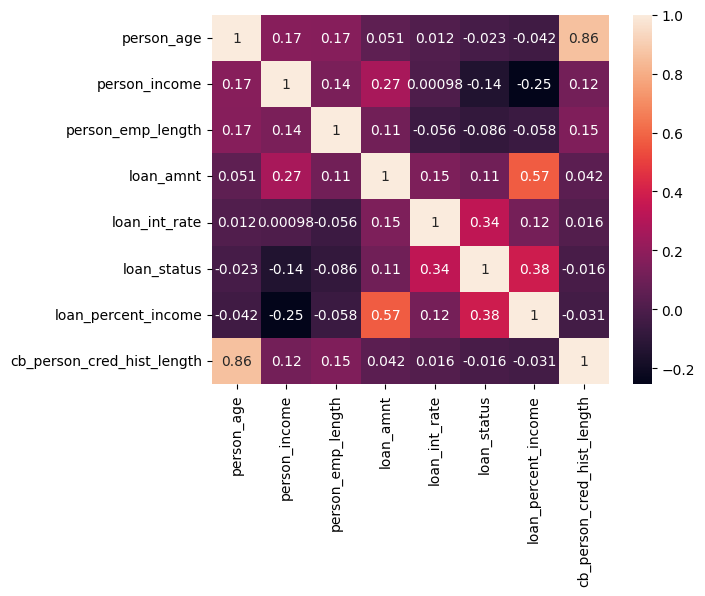

In [131]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

the corr between loan_status and the loan_int_rate is 0.34 so it is not good dropping

<Axes: xlabel='loan_int_rate', ylabel='Count'>

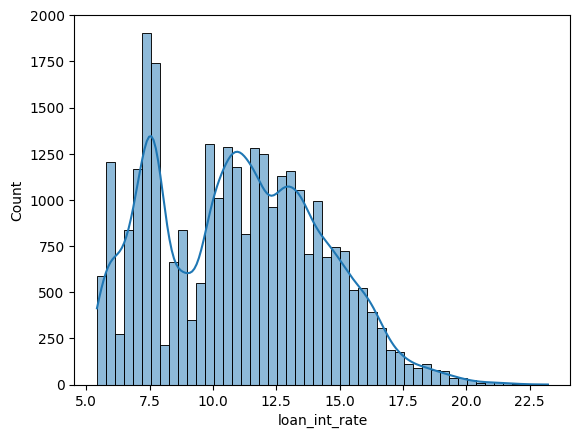

In [132]:
sns.histplot(df['loan_int_rate'], kde=True)

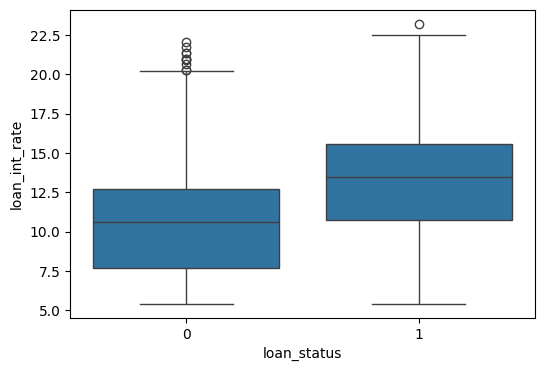

In [133]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='loan_status', y='loan_int_rate')
plt.show()

no many outliners

In [134]:
(df['loan_int_rate'].isnull().sum() / len(df)) * 100

np.float64(9.548343308446967)

In [135]:
mean = df['loan_int_rate'].mean()
mean

np.float64(11.017247177598145)

filling the null with mean as there are not many oultiners and we cannot drop a column with 0.34 correlation

In [136]:
df['loan_int_rate']=df['loan_int_rate'].fillna(mean)

In [137]:
df.info()

<class 'pandas.DataFrame'>
Index: 32414 entries, 1 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32414 non-null  int64  
 1   person_income               32414 non-null  int64  
 2   person_home_ownership       32414 non-null  str    
 3   person_emp_length           32414 non-null  float64
 4   loan_intent                 32414 non-null  str    
 5   loan_grade                  32414 non-null  str    
 6   loan_amnt                   32414 non-null  int64  
 7   loan_int_rate               32414 non-null  float64
 8   loan_status                 32414 non-null  int64  
 9   loan_percent_income         32414 non-null  float64
 10  cb_person_default_on_file   32414 non-null  str    
 11  cb_person_cred_hist_length  32414 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.2 MB


<Axes: xlabel='loan_int_rate', ylabel='Count'>

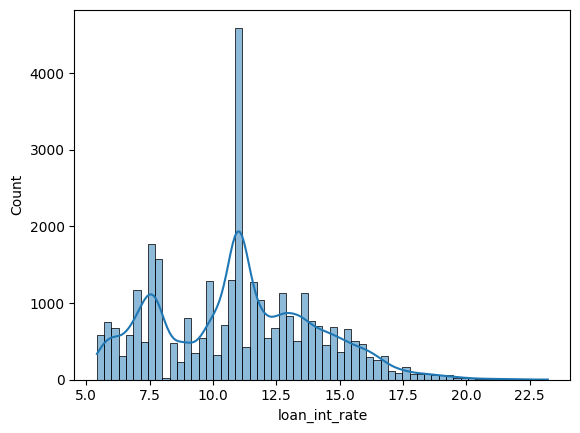

In [138]:
sns.histplot(df['loan_int_rate'], kde=True)

dropped all duplicates and filled nulls need to inspect other columns

In [139]:
df['person_home_ownership'].unique()

<StringArray>
['OWN', 'MORTGAGE', 'RENT', 'OTHER']
Length: 4, dtype: str

In [140]:
df['loan_intent'].unique()


<StringArray>
[        'EDUCATION',           'MEDICAL',           'VENTURE',
          'PERSONAL',   'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION']
Length: 6, dtype: str

In [141]:
df['loan_grade'].unique()

<StringArray>
['B', 'C', 'A', 'D', 'E', 'F', 'G']
Length: 7, dtype: str

In [142]:
df['cb_person_default_on_file'].unique()

<StringArray>
['N', 'Y']
Length: 2, dtype: str

<Axes: xlabel='person_age', ylabel='Count'>

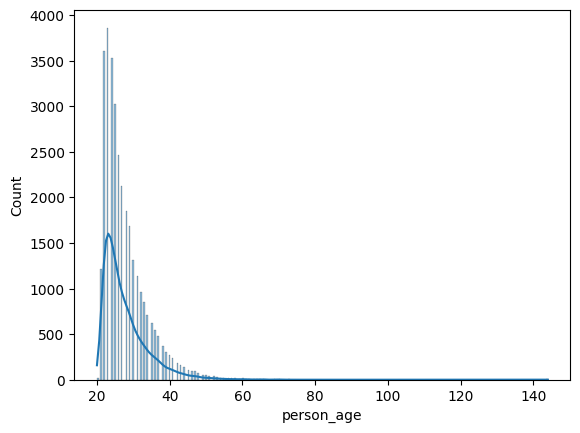

In [143]:
sns.histplot(df['person_age'],kde = True)

since there is no good relation between age and loan_status dropping is good and it has outliners

In [144]:
df.drop(columns=['person_age'],inplace = True)

STARTING ENCODING

In [145]:
df_cleaned = df.copy()

In [146]:
cols=['person_home_ownership','loan_intent']
df_cleaned = pd.get_dummies(df_cleaned,columns=cols)

In [153]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_cleaned['cb_person_default_on_file'] = le.fit_transform(df['cb_person_default_on_file'])
df_cleaned['loan_grade'] = le.fit_transform(df['loan_grade'])

In [156]:
df_cleaned.head(5)


,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
1,9600,5.0,1,1000,11.14,0,0.10,0,2,False,False,True,False,False,True,False,False,False,False
2,9600,1.0,2,5500,12.87,1,0.57,0,3,True,False,False,False,False,False,False,True,False,False
3,65500,4.0,2,35000,15.23,1,0.53,0,2,False,False,False,True,False,False,False,True,False,False
4,54400,8.0,2,35000,14.27,1,0.55,1,4,False,False,False,True,False,False,False,True,False,False
5,9900,2.0,0,2500,7.14,1,0.25,0,2,False,False,True,False,False,False,False,False,False,True


In [159]:
df['cb_person_cred_hist_length'].unique()

array([ 2,  3,  4,  8,  7,  6,  9, 10,  5, 11, 16, 15, 12, 13, 17, 14, 25,
       28, 27, 22, 19, 29, 23, 26, 20, 21, 30, 24, 18])

In [157]:
df_cleaned = df_cleaned.astype(int)

In [158]:
df_scaled = df_cleaned.copy()

In [160]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_cols = ['person_income','person_emp_length','loan_amnt','loan_int_rate','loan_percent_income','cb_person_cred_hist_length']
df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])

In [161]:
df_scaled

,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
1,-0.910912,0.059849,1,-1.359398,0.162865,0,0.0,0,-0.938998,0,0,1,0,0,1,0,0,0,0
2,-0.910912,-0.944257,2,-0.647484,0.483724,1,0.0,0,-0.692635,1,0,0,0,0,0,0,1,0,0
3,-0.009482,-0.191178,2,4.019507,1.446302,1,0.0,0,-0.938998,0,0,0,1,0,0,0,1,0,0
4,-0.188477,0.812928,2,4.019507,1.125443,1,0.0,1,-0.446272,0,0,0,1,0,0,0,1,0,0
5,-0.906074,-0.693231,0,-1.122094,-1.120573,1,0.0,0,-0.938998,0,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32576,-0.211054,-0.944257,2,-0.600023,0.804584,0,0.0,0,5.959167,1,0,0,0,0,0,0,0,1,0
32577,0.869372,-0.191178,0,1.270728,-1.120573,0,0.0,0,3.249174,1,0,0,0,0,0,0,0,1,0
32578,0.159839,-0.442204,1,4.019507,-0.157995,1,0.0,0,5.466441,0,0,0,1,0,0,1,0,0,0
32579,1.353145,0.059849,1,0.855445,0.162865,0,0.0,0,4.973715,1,0,0,0,0,0,0,0,1,0


NOW THE SCALED DATA IS USED FOR LOR,KNN,SVM